In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_goldfeldquandt

plt.rcParams['figure.figsize'] = (7, 5)

In [2]:
def cheddock_description(r):
    ar = abs(r)
    if ar < 0.1:
        return "очень слабая"
    if 0.1 <= ar < 0.3:
        return "слабая"
    if 0.3 <= ar < 0.5:
        return "умеренная"
    if 0.5 <= ar < 0.7:
        return "заметная"
    if 0.7 <= ar < 0.9:
        return "высокая"
    return "весьма высокая"

In [ ]:
def analyze_pair(x, y, alpha=0.05, show_plots=True):
    n = len(x)
    print("n =", n)
    
    r, p_r = stats.pearsonr(x, y)
    print(f"Pearson r = {r:.5f}, p-value = {p_r:.5g}")
    print("Характер связи по Чеддоку:", cheddock_description(r))
    
    t_r = r * np.sqrt((n-2) / (1 - r**2))
    t_crit = stats.t.ppf(1 - alpha/2, df=n-2)
    print(f"t (for r) = {t_r:.4f}, critical t = {t_crit:.4f}")
    print("Корреляция значима (H0: r=0)?", abs(t_r) > t_crit)

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    print(model.summary())

    y_hat = model.fittedvalues
    residuals = model.resid
    SSE = np.sum(residuals**2)
    SST = np.sum((y - np.mean(y))**2)
    SSR = SST - SSE
    k = 1
    MSR = SSR / k
    MSE = SSE / (n - k - 1)
    F = MSR / MSE
    print(f"SSE={SSE:.4f}, SSR={SSR:.4f}, SST={SST:.4f}")
    print(f"F = {F:.4f} (manual), df1={k}, df2={n-k-1}")
    print("F (from model) =", model.fvalue, "p=", model.f_pvalue)

    alpha = alpha
    conf = model.conf_int(alpha=alpha)
    conf_df = pd.DataFrame(conf, columns=['lower','upper'], index=['const','slope'])
    conf_df['coef'] = model.params.values
    print("\nДоверительные интервалы для коэффициентов (level={}):".format(1-alpha))
    print(conf_df)

    x_vals_sorted = np.sort(x)
    dx = np.mean(np.diff(x_vals_sorted)) if len(x_vals_sorted)>1 else 1
    x0_vals = np.array([x_vals_sorted[-1] + (i+1)*dx for i in range(3)])
    X0 = sm.add_constant(x0_vals)
    pred = model.get_prediction(X0)
    pred_summary = pred.summary_frame(alpha=alpha)
    print("\nПрогнозы на 3 шага вперед (mean, mean_ci_lower/upper, obs_ci_lower/upper):")
    print(pd.DataFrame(pred_summary, index=x0_vals))

    if show_plots:
        plt.figure()
        plt.scatter(x, y, label='data')
        xx = np.linspace(np.min(x), np.max(x), 100)
        yy = model.params['const'] + model.params[x.name] * xx if hasattr(x, 'name') else model.params[0] + model.params[1]*xx
        plt.plot(xx, yy, label='regression', linewidth=2)
        plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('Парная зависимость и линия регрессии')
        plt.show()

        plt.figure()
        plt.scatter(y_hat, residuals)
        plt.axhline(0, color='k', linewidth=0.7)
        plt.xlabel('Fitted'); plt.ylabel('Residuals'); plt.title('График остатков')
        plt.show()

    return {'r':r, 't_r':t_r, 'model':model, 'pred_summary':pred_summary}

In [13]:
def chow_test(x, y, d, alpha=0.05):
    X = sm.add_constant(x)
    model_all = sm.OLS(y, X).fit()
    RSS = np.sum(model_all.resid**2)
    n_all = len(y)

    mask0 = (d==0)
    mask1 = (d==1)
    x0, y0 = x[mask0], y[mask0]
    x1, y1 = x[mask1], y[mask1]
    n0, n1 = len(y0), len(y1)
    if n0 < 3 or n1 < 3:
        print("Слишком мало наблюдений в одной из подвыборок для теста Чоу.")
        return None

    model0 = sm.OLS(y0, sm.add_constant(x0)).fit()
    model1 = sm.OLS(y1, sm.add_constant(x1)).fit()
    RSS0 = np.sum(model0.resid**2)
    RSS1 = np.sum(model1.resid**2)

    k = 2
    F = ((RSS - (RSS0 + RSS1)) / k) / ((RSS0 + RSS1) / (n_all - 2*k))
    df1 = k
    df2 = n_all - 2*k
    F_crit = stats.f.ppf(1-alpha, df1, df2)
    p_val = 1 - stats.f.cdf(F, df1, df2)
    print("Chow test:")
    print(f"RSS (pooled)={RSS:.4f}, RSS0={RSS0:.4f}, RSS1={RSS1:.4f}")
    print(f"F = {F:.4f}, df1={df1}, df2={df2}, F_crit={F_crit:.4f}, p={p_val:.4g}")
    if F > F_crit:
        print("Отклоняем H0: деление имеет смысл (подвыборки неоднородны)")
    else:
        print("Не отклоняем H0: деление не улучшает модель")

    plt.figure()
    plt.scatter(x0, y0, label='d=0')
    plt.scatter(x1, y1, label='d=1')
    xx = np.linspace(min(x), max(x), 100)
    plt.plot(xx, model0.params[0] + model0.params[1]*xx, label='fit d=0')
    plt.plot(xx, model1.params[0] + model1.params[1]*xx, label='fit d=1')
    plt.legend(); plt.title('Разбиение по d и регрессии')
    plt.show()

    return {'F':F, 'p':p_val, 'model_all':model_all.summary(), 'model0':model0.summary(), 'model1':model1.summary()}

In [20]:
def heteroskedasticity_tests(x, y, alpha=0.05):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    resid = model.resid
    abs_resid = np.abs(resid)

    print("Spearman test (abs residuals vs x)")
    rs, p_rs = stats.spearmanr(x, abs_resid)
    print(f"Spearman r_s = {rs:.5f}, p = {p_rs:.5g}")
    n = len(x)
    t_rs = rs * np.sqrt((n-2)/(1-rs**2)) if (1-rs**2)>1e-12 else np.inf
    t_crit = stats.t.ppf(1-alpha/2, n-2)
    print(f"t = {t_rs:.4f}, t_crit = {t_crit:.4f}, значима? {abs(t_rs)>t_crit}")

    print("\nGoldfeld-Quandt test (statsmodels)")
    gq_stat, pval, _ = het_goldfeldquandt(y, X, idx=None, drop=0.2, split=0.5)
    print(f"GQ stat = {gq_stat:.4f}, p = {pval:.4g}")
    print("Если p маленькое, то есть гетероскедастичность.")

    df = pd.DataFrame({'x':x, 'y':y}).sort_values('x').reset_index(drop=True)
    n = len(df)
    drop = max(1, n//4)
    m = (n - drop) // 2
    group1 = df.iloc[:m]
    group2 = df.iloc[-m:]
    mod1 = sm.OLS(group1['y'], sm.add_constant(group1['x'])).fit()
    mod2 = sm.OLS(group2['y'], sm.add_constant(group2['x'])).fit()
    SSE1 = np.sum(mod1.resid**2); SSE2 = np.sum(mod2.resid**2)
    df1 = m - 2; df2 = m - 2
    F_manual = (max(SSE1,SSE2)/df1) / (min(SSE1,SSE2)/df2) if (SSE2>0 and df1>0 and df2>0) else np.nan
    F_crit = stats.f.ppf(1-alpha, df1, df2) if (df1>0 and df2>0) else np.nan
    print("\nGoldfeld-Quandt (manual):")
    print(f"SSE1={SSE1:.4f}, df1={df1}; SSE2={SSE2:.4f}, df2={df2}")
    print(f"F = {F_manual:.4f}, F_crit={F_crit:.4f} (if F>F_crit -> heteroskedasticity)")

    return {'spearman':(rs, p_rs), 'gq_stats':(gq_stat, pval), 'gq_manual':(F_manual, F_crit)}

n = 99
Pearson r = -0.98441, p-value = 4.9714e-75
Характер связи по Чеддоку: весьма высокая
t (for r) = -55.1296, critical t = 1.9847
Корреляция значима (H0: r=0)? True

--- Регрессия ---
                             OLS Regression Results                            
Dep. Variable:     -4.6608563318052205   R-squared:                       0.969
Model:                             OLS   Adj. R-squared:                  0.969
Method:                  Least Squares   F-statistic:                     3039.
Date:                 Fri, 07 Nov 2025   Prob (F-statistic):           4.97e-75
Time:                         10:43:41   Log-Likelihood:                -199.83
No. Observations:                   99   AIC:                             403.7
Df Residuals:                       97   BIC:                             408.8
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
            

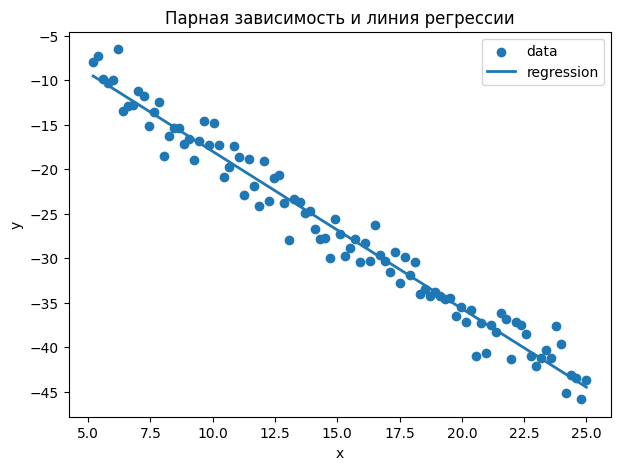

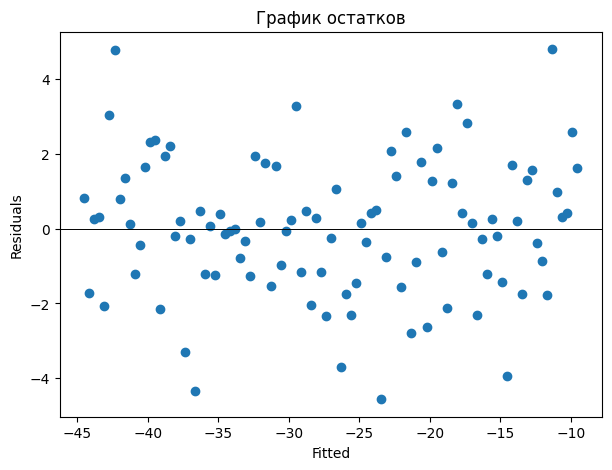

{'r': np.float64(-0.9844143268618922),
 't_r': np.float64(-55.12959904335154),
 'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x279c499b440>,
 'pred_summary':         mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
 0 -44.857201  0.372665     -45.596838     -44.117564    -48.583159   
 1 -45.213942  0.378297     -45.964757     -44.463127    -48.942135   
 2 -45.570683  0.383955     -46.332727     -44.808638    -49.301153   
 
    obs_ci_upper  
 0    -41.131243  
 1    -41.485749  
 2    -41.840212  }

In [9]:
df1 = pd.read_csv("data/5/1.txt")
x1 = df1.iloc[:,0]
y1 = df1.iloc[:,1]
analyze_pair(x1, y1) 

Chow test:
RSS (pooled)=132813.1283, RSS0=15.2071, RSS1=857.4859
F = 14740.7988, df1=2, df2=195, F_crit=3.0422, p=1.11e-16
Отклоняем H0: деление имеет смысл (подвыборки неоднородны)


C:\Users\borga\AppData\Local\Temp\ipykernel_22900\2554764747.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(xx, model0.params[0] + model0.params[1]*xx, label='fit d=0')
C:\Users\borga\AppData\Local\Temp\ipykernel_22900\2554764747.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(xx, model1.params[0] + model1.params[1]*xx, label='fit d=1')


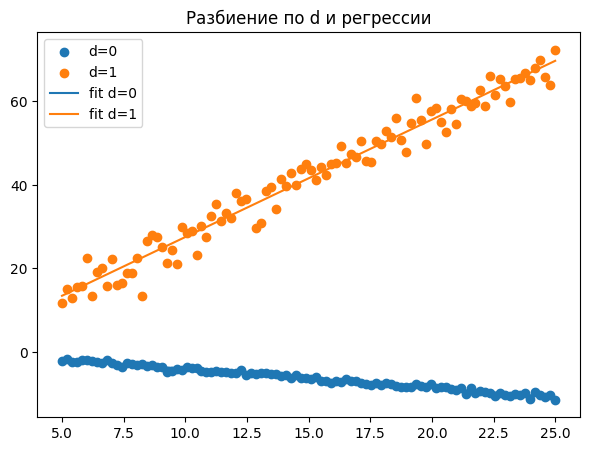

{'F': np.float64(14740.79880574199),
 'p': np.float64(1.1102230246251565e-16),
 'model_all': <class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:      37.88535815720651   R-squared:                       0.067
 Model:                            OLS   Adj. R-squared:                  0.062
 Method:                 Least Squares   F-statistic:                     14.17
 Date:                Fri, 07 Nov 2025   Prob (F-statistic):           0.000221
 Time:                        12:33:43   Log-Likelihood:                -929.46
 No. Observations:                 199   AIC:                             1863.
 Df Residuals:                     197   BIC:                             1869.
 Df Model:                           1                                         
 Covariance Type:            nonrobust                                         
                          coef    std err          t      

In [14]:
df2 = pd.read_csv("data/5/2.txt")
x2 = df2.iloc[:,0]
d = df2.iloc[:,1]
y2 = df2.iloc[:,3]
chow_test(x2, y2, d)

In [21]:
df3 = pd.read_csv("data/5/3.txt")
x3 = df3.iloc[:,0]
y3 = df3.iloc[:,1]
heteroskedasticity_tests(x3, y3)

Spearman test (abs residuals vs x)
Spearman r_s = 0.48975, p = 2.6797e-07
t = 5.5323, t_crit = 1.9847, значима? True

Goldfeld-Quandt test (statsmodels)
GQ stat = 5.2451, p = 5.011e-06
Если p маленькое, то есть гетероскедастичность.

Goldfeld-Quandt (manual):
SSE1=7045.7974, df1=35; SSE2=52327.1559, df2=35
F = 7.4267, F_crit=1.7571 (if F>F_crit -> heteroskedasticity)


{'spearman': (np.float64(0.48974644403215833),
  np.float64(2.6796805849009695e-07)),
 'gq_stats': (np.float64(5.245125095981307), np.float64(5.01134009397845e-06)),
 'gq_manual': (np.float64(7.4267188387561625), np.float64(1.7571395260834919))}

n = 99
Pearson r = -0.98441, p-value = 4.9714e-75
Характер связи по Чеддоку: весьма высокая
t (for r) = -55.1296, critical t = 1.9847
Корреляция значима (H0: r=0)? True

--- Регрессия ---
                             OLS Regression Results                            
Dep. Variable:     -4.6608563318052205   R-squared:                       0.969
Model:                             OLS   Adj. R-squared:                  0.969
Method:                  Least Squares   F-statistic:                     3039.
Date:                 Fri, 07 Nov 2025   Prob (F-statistic):           4.97e-75
Time:                         12:44:26   Log-Likelihood:                -199.83
No. Observations:                   99   AIC:                             403.7
Df Residuals:                       97   BIC:                             408.8
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
            

C:\Users\borga\AppData\Local\Temp\ipykernel_22900\473904153.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yy_center = model.params[0] + model.params[1] * xx
C:\Users\borga\AppData\Local\Temp\ipykernel_22900\473904153.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(xx, yy_center, 'r-', linewidth=2.5, label=f'Основная модель: $y = {model.params[0]:.2f} + {model.params[1]:.2f}x$')


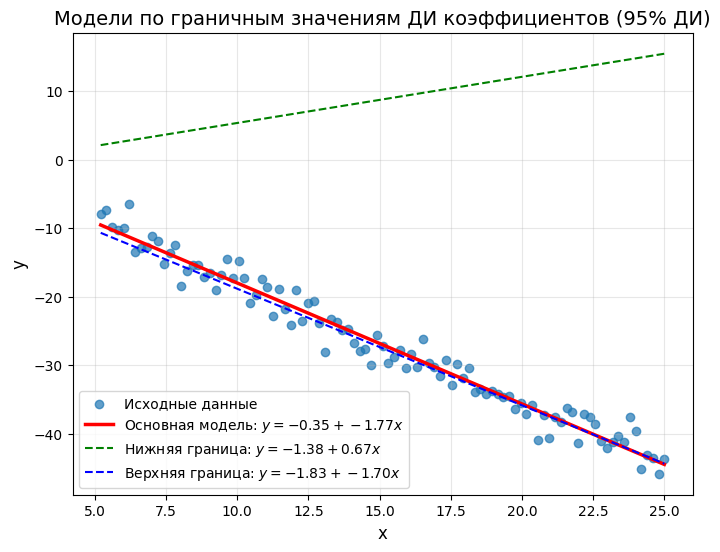

In [16]:
# Сначала получаем результаты без стандартных графиков
res = analyze_pair(x1, y1, show_plots=False)
model = res['model']

# Доверительные интервалы для коэффициентов (95%)
conf = model.conf_int(alpha=0.05)
const_lower, const_upper = conf[0]
slope_lower, slope_upper = conf[1]

# Генерация точек для визуализации
xx = np.linspace(x1.min(), x1.max(), 100)
yy_center = model.params[0] + model.params[1] * xx
yy_lower = const_lower + slope_lower * xx
yy_upper = const_upper + slope_upper * xx

plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, alpha=0.7, label='Исходные данные')
plt.plot(xx, yy_center, 'r-', linewidth=2.5, label=f'Основная модель: $y = {model.params[0]:.2f} + {model.params[1]:.2f}x$')
plt.plot(xx, yy_lower, 'g--', linewidth=1.5, label=f'Нижняя граница: $y = {const_lower:.2f} + {slope_lower:.2f}x$')
plt.plot(xx, yy_upper, 'b--', linewidth=1.5, label=f'Верхняя граница: $y = {const_upper:.2f} + {slope_upper:.2f}x$')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Модели по граничным значениям ДИ коэффициентов (95% ДИ)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

C:\Users\borga\AppData\Local\Temp\ipykernel_22900\93718253.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f'Модель: $R^2 = {model.rsquared:.3f}$, $p_{{slope}} = {model.pvalues[1]:.2e}$')
C:\Users\borga\AppData\Local\Temp\ipykernel_22900\93718253.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"const = {model.params[0]:.3f} (p={model.pvalues[0]:.3f})\n"
C:\Users\borga\AppData\Local\Temp\ipykernel_22900\93718253.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To a

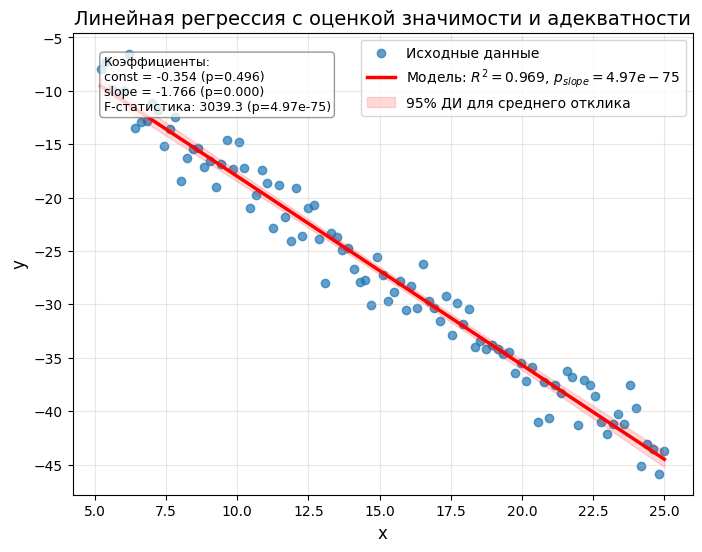

In [17]:
# Генерация предсказаний с доверительными интервалами
X_new = sm.add_constant(xx)
pred = model.get_prediction(X_new)
pred_summary = pred.summary_frame(alpha=0.05)  # 95% доверительный интервал

plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, alpha=0.7, label='Исходные данные')

# Основная линия регрессии
plt.plot(xx, pred_summary['mean'], 'r-', linewidth=2.5, 
         label=f'Модель: $R^2 = {model.rsquared:.3f}$, $p_{{slope}} = {model.pvalues[1]:.2e}$')

# Доверительный интервал для среднего отклика
plt.fill_between(xx, 
                 pred_summary['mean_ci_lower'], 
                 pred_summary['mean_ci_upper'],
                 color='red', alpha=0.15, label='95% ДИ для среднего отклика')

# Аннотация статистики
stats_text = (f"Коэффициенты:\n"
              f"const = {model.params[0]:.3f} (p={model.pvalues[0]:.3f})\n"
              f"slope = {model.params[1]:.3f} (p={model.pvalues[1]:.3f})\n"
              f"F-статистика: {model.fvalue:.1f} (p={model.f_pvalue:.2e})")

plt.annotate(stats_text, xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
             fontsize=9, verticalalignment='top')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Линейная регрессия с оценкой значимости и адекватности', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.show()